# 03 — Customer Segmentation (KMeans)

**Goal:** Cluster customers into meaningful groups based on behavioral and demographic features,
then overlay churn risk to build **actionable business profiles** per segment.

**Pipeline:**
1. Feature selection for clustering
2. Optimal K selection — Elbow method + Silhouette score
3. KMeans training
4. Segment profiling
5. Churn rate × segment analysis
6. Business naming of segments
7. Saving artifacts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/raw/telco.csv')

# --- Cleaning ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().copy()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [3]:
# --- Feature engineering for clustering ---
# We select interpretable features that have clear business meaning.
# Avoiding full one-hot encoding keeps the clusters human-readable.

CLUSTER_FEATURES = [
    'tenure',           # months as a customer
    'MonthlyCharges',   # monthly spend
    'TotalCharges',     # lifetime spend (correlated but informative)
    'SeniorCitizen',    # already binary (0/1)
]

# Derived binary features
df['HasTechSupport'] = (df['TechSupport']    == 'Yes').astype(int)
df['HasOnlineSec']   = (df['OnlineSecurity'] == 'Yes').astype(int)
df['IsMonthly']      = (df['Contract']       == 'Month-to-month').astype(int)
df['HasMultiLines']  = (df['MultipleLines']  == 'Yes').astype(int)

CLUSTER_FEATURES += ['HasTechSupport', 'HasOnlineSec', 'IsMonthly', 'HasMultiLines']

X_clust = df[CLUSTER_FEATURES].copy()
print('Clustering features:', CLUSTER_FEATURES)
X_clust.describe()

Clustering features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'HasTechSupport', 'HasOnlineSec', 'IsMonthly', 'HasMultiLines']


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,HasTechSupport,HasOnlineSec,IsMonthly,HasMultiLines
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,0.162400,0.290102,0.286547,0.551052,0.421928
std,24.545260,30.085974,2266.771362,0.368844,0.453842,0.452180,0.497422,0.493902
min,1.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,35.587500,401.450000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,55.000000,89.862500,3794.737500,0.000000,1.000000,1.000000,1.000000,1.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
# --- Standardization ---
# KMeans is distance-based — scaling is mandatory.
scaler_clust = StandardScaler()
X_scaled = scaler_clust.fit_transform(X_clust)

## 2. Optimal K — Elbow Method + Silhouette Score

In [5]:
K_RANGE = range(2, 10)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))
    print(f'k={k}  |  inertia={km.inertia_:,.0f}  |  silhouette={silhouettes[-1]:.4f}')

k=2  |  inertia=39,668  |  silhouette=0.3004
k=3  |  inertia=33,385  |  silhouette=0.2503
k=4  |  inertia=28,440  |  silhouette=0.2821
k=5  |  inertia=25,209  |  silhouette=0.2862
k=6  |  inertia=22,472  |  silhouette=0.2968
k=7  |  inertia=20,743  |  silhouette=0.3148
k=8  |  inertia=19,195  |  silhouette=0.3241
k=9  |  inertia=17,852  |  silhouette=0.3271


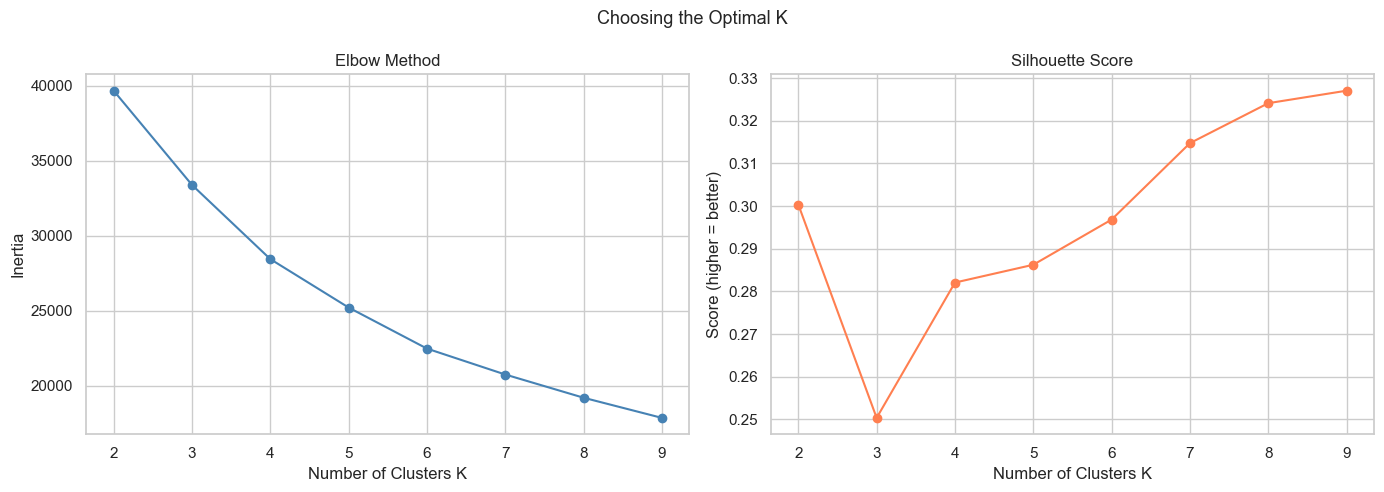


→ Best K by silhouette score: 9


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_RANGE), silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Score (higher = better)')

plt.suptitle('Choosing the Optimal K', fontsize=13)
plt.tight_layout()
plt.savefig('../models/clustering_k_choice.png', dpi=150)
plt.show()

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'\n→ Best K by silhouette score: {best_k}')

## 3. Train Final KMeans Model

In [7]:
# You can override with K_FINAL = 4 for cleaner business storytelling.
# Otherwise best_k is selected automatically.
K_FINAL = best_k  # or: K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df['Segment'] = kmeans.fit_predict(X_scaled)

print(f'Clusters created: {K_FINAL}')
print(df['Segment'].value_counts().sort_index())

Clusters created: 9
Segment
0     567
1     547
2     716
3    1637
4    1109
5     679
6     666
7     678
8     433
Name: count, dtype: int64


## 4. 2D Visualization via PCA

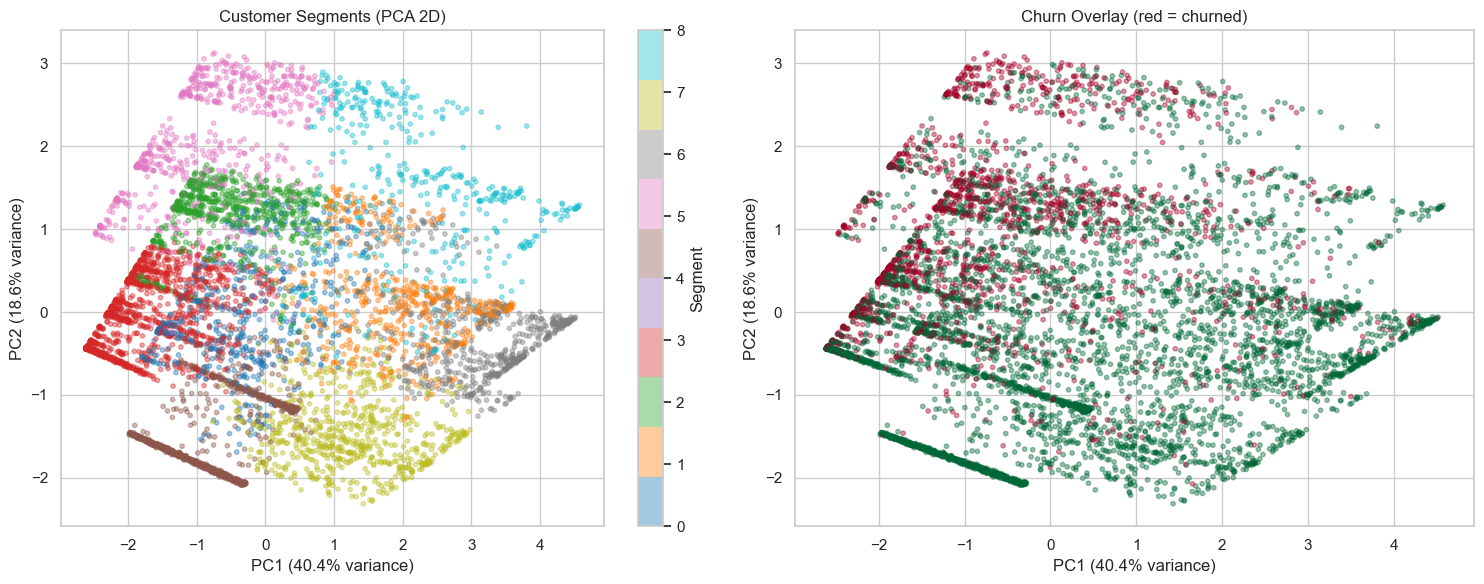

In [8]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

df['PCA1'] = X_2d[:, 0]
df['PCA2'] = X_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter = axes[0].scatter(
    df['PCA1'], df['PCA2'],
    c=df['Segment'], cmap='tab10', alpha=0.4, s=10
)
axes[0].set_title('Customer Segments (PCA 2D)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(scatter, ax=axes[0], label='Segment')

axes[1].scatter(
    df['PCA1'], df['PCA2'],
    c=df['Churn'], cmap='RdYlGn_r', alpha=0.4, s=10
)
axes[1].set_title('Churn Overlay (red = churned)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

plt.tight_layout()
plt.savefig('../models/clustering_pca.png', dpi=150)
plt.show()

## 5. Segment Profiling

In [9]:
profile_cols = CLUSTER_FEATURES + ['Churn']
segment_profile = df.groupby('Segment')[profile_cols].mean().round(3)
segment_profile['count']        = df.groupby('Segment').size()
segment_profile['churn_rate_%'] = (segment_profile['Churn'] * 100).round(1)

print('=== Segment Profile Summary ===')
segment_profile

=== Segment Profile Summary ===


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,HasTechSupport,HasOnlineSec,IsMonthly,HasMultiLines,Churn,count,churn_rate_%
Segment,,,,,,,,,,,
0,19.496,67.952,1343.117,0.000,0.252,1.000,0.898,0.323,0.268,567,26.8
1,56.742,94.464,5393.598,0.000,0.554,0.000,0.241,0.865,0.185,547,18.5
2,17.800,79.178,1447.844,0.000,0.135,0.000,0.980,1.000,0.513,716,51.3
3,10.255,50.396,543.331,0.000,0.136,0.000,0.996,0.000,0.392,1637,39.2
4,41.060,25.382,1031.768,0.022,0.005,0.005,0.002,0.262,0.031,1109,3.1
5,16.817,74.064,1262.672,1.000,0.087,0.112,0.966,0.457,0.567,679,56.7
6,62.917,94.932,5980.870,0.000,0.683,1.000,0.102,0.941,0.084,666,8.4
7,47.711,65.823,3125.266,0.009,0.824,0.737,0.035,0.025,0.062,678,6.2
8,58.106,92.333,5345.173,1.000,0.450,0.462,0.349,0.808,0.210,433,21.0


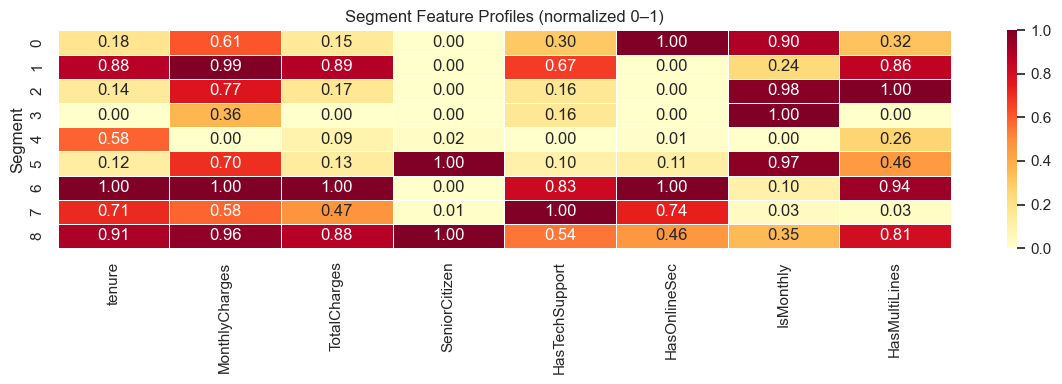

In [10]:
# Normalized heatmap for cross-segment comparison
profile_norm = segment_profile[CLUSTER_FEATURES].copy()
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

plt.figure(figsize=(12, 4))
sns.heatmap(
    profile_norm,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Segment Feature Profiles (normalized 0–1)')
plt.tight_layout()
plt.savefig('../models/clustering_heatmap.png', dpi=150)
plt.show()

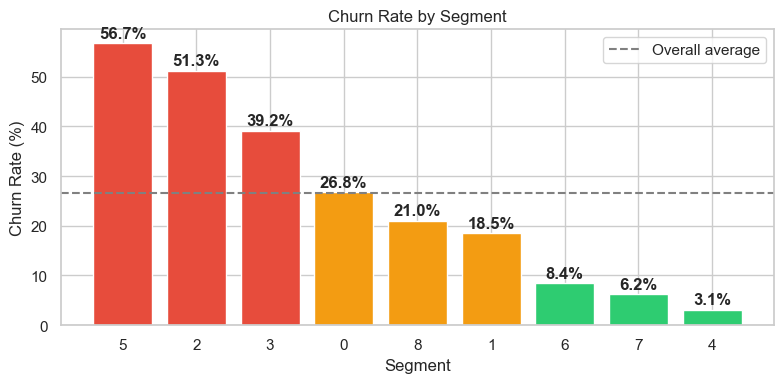

In [11]:
churn_by_seg = df.groupby('Segment')['Churn'].mean().sort_values(ascending=False)

colors = ['#e74c3c' if v > 0.30 else '#f39c12' if v > 0.15 else '#2ecc71'
          for v in churn_by_seg.values]

plt.figure(figsize=(8, 4))
bars = plt.bar(churn_by_seg.index.astype(str), churn_by_seg.values * 100, color=colors)
plt.axhline(df['Churn'].mean() * 100, color='gray', linestyle='--', label='Overall average')
plt.title('Churn Rate by Segment')
plt.xlabel('Segment')
plt.ylabel('Churn Rate (%)')
plt.legend()
for bar, val in zip(bars, churn_by_seg.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../models/clustering_churnrate.png', dpi=150)
plt.show()

## 6. Business Naming of Segments

Adjust names below based on what you observe in `segment_profile`.
The function auto-assigns names based on churn rank + tenure + contract type.

In [12]:
churn_rank = df.groupby('Segment')['Churn'].mean().rank(ascending=False).astype(int)

def name_segment(seg_id, profile, churn_rank):
    rank       = churn_rank[seg_id]
    tenure     = profile.loc[seg_id, 'tenure']
    monthly    = profile.loc[seg_id, 'MonthlyCharges']
    is_monthly = profile.loc[seg_id, 'IsMonthly']

    if rank == 1:
        return 'At-Risk Newcomers'    # low tenure, month-to-month, highest churn
    elif rank == 2 and monthly > profile['MonthlyCharges'].mean():
        return 'High-Value Churners'  # high spend but still leaving
    elif tenure > profile['tenure'].mean() and is_monthly < 0.4:
        return 'Loyal Long-term'      # long tenure, annual/two-year contract
    else:
        return 'Stable Mid-tier'      # average profile, low churn

segment_names = {
    seg: name_segment(seg, segment_profile, churn_rank)
    for seg in df['Segment'].unique()
}

df['SegmentName'] = df['Segment'].map(segment_names)

print('=== Segment → Business Name Mapping ===')
for seg, name in sorted(segment_names.items()):
    churn_r = df[df['Segment'] == seg]['Churn'].mean()
    count   = (df['Segment'] == seg).sum()
    print(f'  Segment {seg} → "{name}"  |  churn={churn_r:.1%}  |  n={count}')

=== Segment → Business Name Mapping ===
  Segment 0 → "Stable Mid-tier"  |  churn=26.8%  |  n=567
  Segment 1 → "Loyal Long-term"  |  churn=18.5%  |  n=547
  Segment 2 → "High-Value Churners"  |  churn=51.3%  |  n=716
  Segment 3 → "Stable Mid-tier"  |  churn=39.2%  |  n=1637
  Segment 4 → "Loyal Long-term"  |  churn=3.1%  |  n=1109
  Segment 5 → "At-Risk Newcomers"  |  churn=56.7%  |  n=679
  Segment 6 → "Loyal Long-term"  |  churn=8.4%  |  n=666
  Segment 7 → "Loyal Long-term"  |  churn=6.2%  |  n=678
  Segment 8 → "Loyal Long-term"  |  churn=21.0%  |  n=433


In [13]:
# Final summary table
df.groupby(['Segment', 'SegmentName'])['Churn'].agg(['mean', 'count']).rename(
    columns={'mean': 'churn_rate', 'count': 'n_customers'}
).round(3)

,,churn_rate,n_customers
Segment,SegmentName,,
0,Stable Mid-tier,0.268,567
1,Loyal Long-term,0.185,547
2,High-Value Churners,0.513,716
3,Stable Mid-tier,0.392,1637
4,Loyal Long-term,0.031,1109
5,At-Risk Newcomers,0.567,679
6,Loyal Long-term,0.084,666
7,Loyal Long-term,0.062,678
8,Loyal Long-term,0.210,433


## 7. Save Artifacts

In [16]:
joblib.dump(kmeans,       '../models/kmeans_model.pkl')
joblib.dump(scaler_clust, '../models/scaler_cluster.pkl')

with open('../models/segment_names.json', 'w') as f:
    json.dump({str(k): v for k, v in segment_names.items()}, f, indent=2)


print('Saved:')
print('  models/kmeans_model.pkl')
print('  models/scaler_cluster.pkl')
print('  models/segment_names.json')


Saved:
  models/kmeans_model.pkl
  models/scaler_cluster.pkl
  models/segment_names.json


## Summary

| Segment | Profile | Churn Risk | Recommended Action |
|---|---|---|---|
| At-Risk Newcomers | New customers, month-to-month contract | 🔴 High | Early onboarding + offer annual contract discount |
| High-Value Churners | High monthly spend, still leaving | 🟠 Medium-High | Premium retention offer, loyalty gesture |
| Stable Mid-tier | Average profile | 🟡 Medium | Upsell services (tech support, security) |
| Loyal Long-term | Long tenure, long-term contract | 🟢 Low | Loyalty rewards program |

